7th Test - Wheelchair segmentation - Image 230 - 512x512


(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

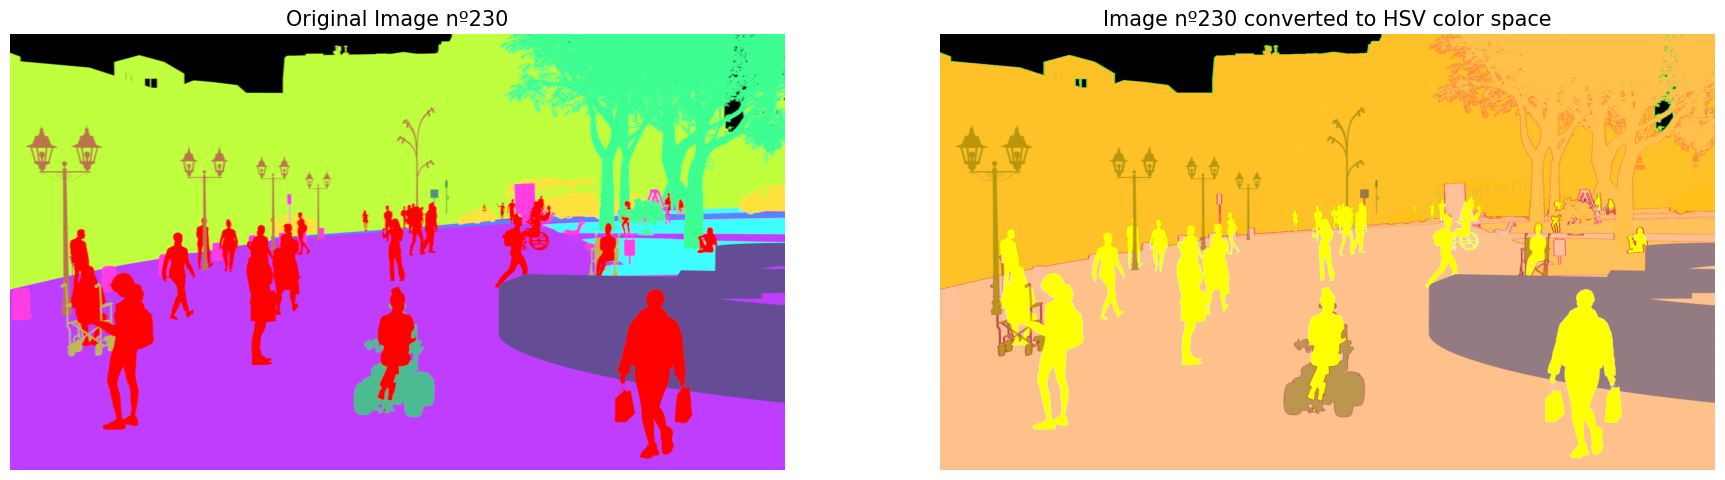

In [ ]:
import sys
import os

# Add the project root folder path to sys.path
# project_path = '/home/santiago/Doctorado/Entrenamientos/renato/pucpr_pibic_semantic_segmentation'
project_path = '/media/renato/Data/Work/pucpr_pibic_semantic_segmentation/'
sys.path.append(os.path.abspath(project_path))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
# base_mask_folder: str = r"C:\Users\SLR02\Pictures\prueba 3\FinalImagePPM_Mask"
# output_folder: str = os.getenv("OUTPUT_FOLDER")
# mask_path: str = os.path.join(base_mask_folder, f"{441}.png")

base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)

# Setup Plot
plt.figure(figsize=[22,22])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Original Image nº{img_number}",fontdict={'fontsize': 15})
plt.axis('off')
# Plotting HSV image
plt.subplot(122)
plt.imshow(hsv_img[:,:,::-1])
plt.title(f"Image nº{img_number} converted to HSV color space",fontdict={'fontsize': 15})
plt.axis('off')

In [24]:
# Inspect the actual color values ​​in the image for each pixel
cv.imshow("Inspect Image", hsv_img)
cv.waitKey(0)
cv.destroyAllWindows()

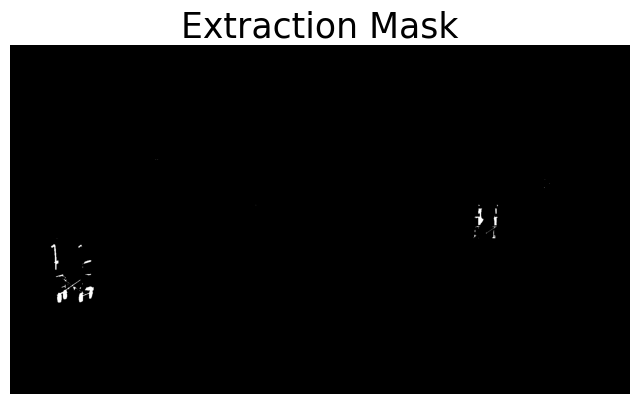

In [2]:
### Process 1 - Extraction of the desired color ###
# Define limits for the color you want to extract in HSV
lower_bound = np.array([20, 140, 178]) # Hue, Saturation, Value
upper_bound = np.array([31, 151, 198]) # Hue, Saturation, Value
mask_extraction = cv.inRange(hsv_img, lower_bound, upper_bound)

# Display the extraction mask
plt.figure(figsize=[8, 8])
plt.imshow(mask_extraction, cmap='gray')
plt.title("Extraction Mask", fontdict={'fontsize': 25})
plt.axis('off')
plt.show()

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

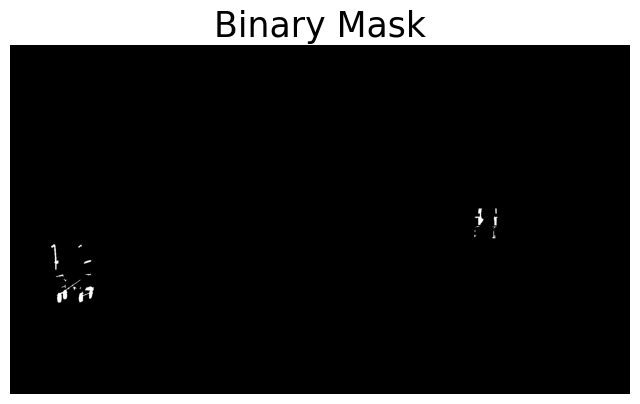

In [3]:
### Process 2 - Find Contours and Remove Noise
contours, hierarchy = cv.findContours(mask_extraction, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

# Create empty mask
filtered_mask = np.zeros_like(mask_extraction)

# Define minimum area
min_area = 5

# Filter by area and preserve structure
for contour in contours:
    area = cv.contourArea(contour)
    if area >= min_area:
        # Create mask for this specific contour
        temp_mask = np.zeros_like(mask_extraction)
        cv.drawContours(temp_mask, [contour], -1, (255), -1)
        
        # Preserve original pixels within outline
        contour_region = cv.bitwise_and(mask_extraction, temp_mask)
        filtered_mask = cv.bitwise_or(filtered_mask, contour_region)

# 3.4 - Visualize updated mask
plt.figure(figsize=[8,8])
plt.imshow(filtered_mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')


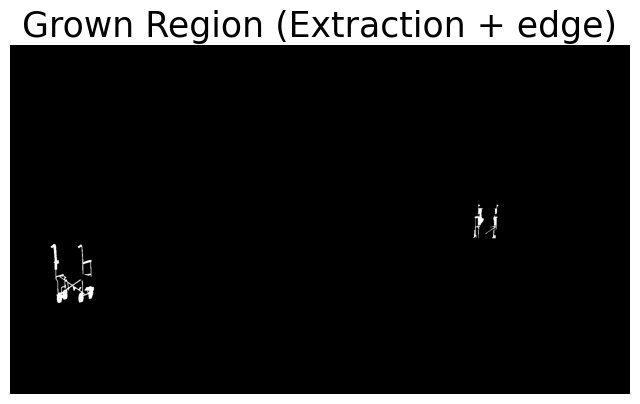

In [4]:
### Process 3 - Region Growth
import collections


### Define target color ###
# Average extraction range: ((25+31)//2, (136+151)//2, (188+198)//2) = [28, 143, 193]
target_color = np.array([(25 + 31) // 2, (136 + 151) // 2, (188 + 198) // 2])

### Region growing from extraction ###
# A region growing mask is created. Initially, it contains the extraction.
region_mask = np.zeros_like(filtered_mask, dtype=np.uint8)
region_mask[filtered_mask == 255] = 255

# We use a queue to implement region growth
queue = collections.deque()

# We add the initial pixels of the extraction
indexes = np.column_stack(np.where(filtered_mask == 255))
for index in indexes:
    queue.append(tuple(index))

# Helper function: boundary condition based on the obtained ranges in HSV
def fulfill_condition(H, S, V):
    return ((12 <= H <= 36) and (41 <= S <= 180) and (183 <= V <= 213)) # Adjusted values for growth
    # return ((28 <= H <= 33) and (41 <= S <= 180) and (183 <= V <= 213)) # Better for blur effect but bad results for other images

# We perform the growth: for each pixel in the region, its neighbors are analyzed.
while queue:
    i, j = queue.popleft()
    # For 8 Neighbors (it's possible expand the neighborhood if necessary)
    for di, dj in [
                    (-1, -1), (-1, 0), (-1, 1),
                    ( 0, -1),          ( 0, 1),
                    ( 1, -1), ( 1, 0), ( 1, 1)
                ]:
        ni, nj = i + di, j + dj
        # Check that the neighbor is within the image
        if 0 <= ni < hsv_img.shape[0] and 0 <= nj < hsv_img.shape[1]:
            # If the neighbor is not yet part of the growth region:
            if region_mask[ni, nj] == 0:
                H, S, V = hsv_img[ni, nj]
                if fulfill_condition(H, S, V):
                    region_mask[ni, nj] = 255
                    queue.append((ni, nj))

# Display the grown region
plt.figure(figsize=[8, 8])
plt.imshow(region_mask, cmap='gray')
plt.title("Grown Region (Extraction + edge)", fontdict={'fontsize': 25})
plt.axis('off')
plt.show()


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

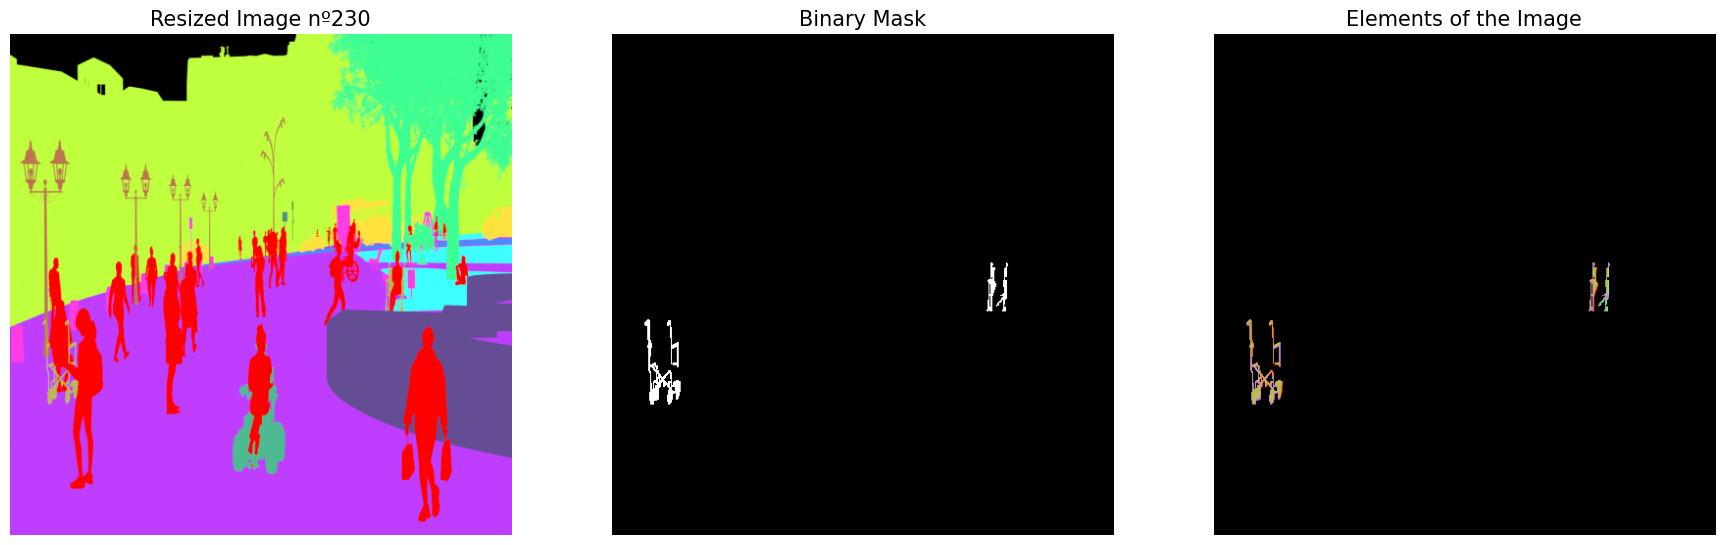

In [5]:
# Morphologic Operation
# 3. Post-processing
kernel = np.ones((2,2), np.uint8)
mask = cv.morphologyEx(region_mask, cv.MORPH_CLOSE, kernel) # Close small holes


# Resize mask and image
resized_mask = cv.resize(mask, (512, 512), interpolation=cv.INTER_AREA)
binary_mask = np.where(resized_mask > 0, 255, 0).astype(np.uint8) # threshold = 0


# Visualize Segmentation
# Resize Original Image
bgr_img = cv.resize(bgr_img, (512, 512), interpolation=cv.INTER_AREA)
# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=binary_mask)

# Setup Plot
plt.figure(figsize=[22,22])
# Plotting original image
plt.subplot(131)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Resized Image nº{img_number}",fontdict={'fontsize': 15})
plt.axis('off')
# Plotting binary mask
plt.subplot(132)
plt.imshow(binary_mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 15})
plt.axis('off')
# Plotting result
plt.subplot(133)
plt.imshow(result[:,:,::-1])
plt.title("Elements of the Image",fontdict={'fontsize':15})
plt.axis('off')

In [6]:
cv.imshow("Inspect Image", result)
cv.waitKey(0)
cv.destroyAllWindows()

2nd Test - Wheelchair Segmentation - Image 000 - 512x512

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

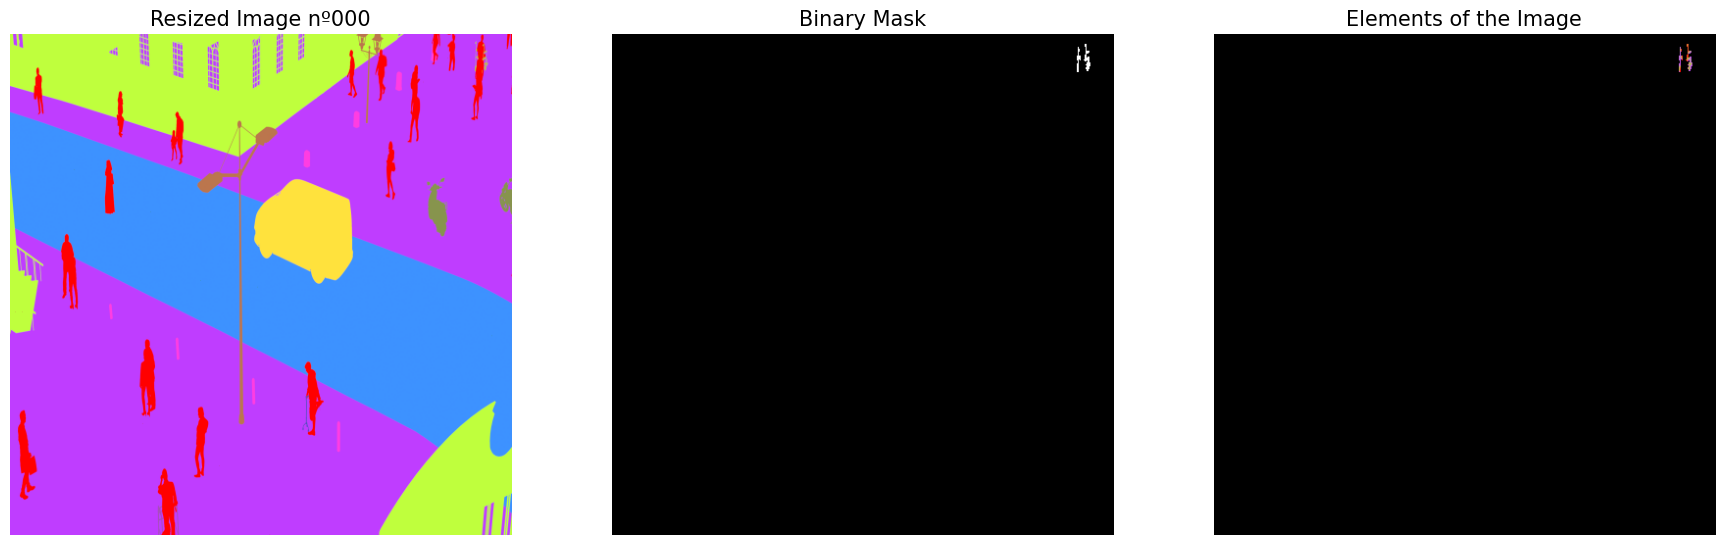

In [ ]:
import sys
import os

# Add the project root folder path to sys.path
# project_path = '/home/santiago/Doctorado/Entrenamientos/renato/pucpr_pibic_semantic_segmentation'
project_path = '/media/renato/Data/Work/pucpr_pibic_semantic_segmentation/'
sys.path.append(os.path.abspath(project_path))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
# base_mask_folder: str = r"C:\Users\SLR02\Pictures\prueba 3\FinalImagePPM_Mask"
# output_folder: str = os.getenv("OUTPUT_FOLDER")
# mask_path: str = os.path.join(base_mask_folder, f"{441}.png")

base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)

### Process 1 - Extraction of the desired color ###
# Define limits for the color you want to extract in HSV
lower_bound = np.array([20, 140, 178]) # Hue, Saturation, Value
upper_bound = np.array([31, 151, 198]) # Hue, Saturation, Value
mask_extraction = cv.inRange(hsv_img, lower_bound, upper_bound)


### Process 2 - Find Contours and Remove Noise
contours, hierarchy = cv.findContours(mask_extraction, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

# Create empty mask
filtered_mask = np.zeros_like(mask_extraction)

# Define minimum area
min_area = 5

# Filter by area and preserve structure
for contour in contours:
    area = cv.contourArea(contour)
    if area >= min_area:
        # Create mask for this specific contour
        temp_mask = np.zeros_like(mask_extraction)
        cv.drawContours(temp_mask, [contour], -1, (255), -1)
        
        # Preserve original pixels within outline
        contour_region = cv.bitwise_and(mask_extraction, temp_mask)
        filtered_mask = cv.bitwise_or(filtered_mask, contour_region)


### Process 3 - Region Growth
import collections


### Define target color ###
# Average extraction range: ((25+31)//2, (136+151)//2, (188+198)//2) = [28, 143, 193]
target_color = np.array([(25 + 31) // 2, (136 + 151) // 2, (188 + 198) // 2])

### Region growing from extraction ###
# A region growing mask is created. Initially, it contains the extraction.
region_mask = np.zeros_like(filtered_mask, dtype=np.uint8)
region_mask[filtered_mask == 255] = 255

# We use a queue to implement region growth
queue = collections.deque()

# We add the initial pixels of the extraction
indexes = np.column_stack(np.where(filtered_mask == 255))
for index in indexes:
    queue.append(tuple(index))

# Helper function: boundary condition based on the obtained ranges in HSV
def fulfill_condition(H, S, V):
    return ((12 <= H <= 36) and (41 <= S <= 180) and (183 <= V <= 213)) # Adjusted values for growth
    # return ((28 <= H <= 33) and (41 <= S <= 180) and (183 <= V <= 213)) # Better for blur effect but bad results for other images

# We perform the growth: for each pixel in the region, its neighbors are analyzed.
while queue:
    i, j = queue.popleft()
    # For 8 Neighbors (it's possible expand the neighborhood if necessary)
    for di, dj in [
                    (-1, -1), (-1, 0), (-1, 1),
                    (0, -1),           (0, 1),
                    (1, -1),  (1, 0),  (1, 1)
                ]:
        ni, nj = i + di, j + dj
        # Check that the neighbor is within the image
        if 0 <= ni < hsv_img.shape[0] and 0 <= nj < hsv_img.shape[1]:
            # If the neighbor is not yet part of the growth region:
            if region_mask[ni, nj] == 0:
                H, S, V = hsv_img[ni, nj]
                if fulfill_condition(H, S, V):
                    region_mask[ni, nj] = 255
                    queue.append((ni, nj))


# Morphologic Operation
# 3. Post-processing
kernel = np.ones((2,2), np.uint8)
mask = cv.morphologyEx(region_mask, cv.MORPH_CLOSE, kernel) # Close small holes


# Resize mask and image
resized_mask = cv.resize(mask, (512, 512), interpolation=cv.INTER_AREA)
binary_mask = np.where(resized_mask > 0, 255, 0).astype(np.uint8) # threshold = 0


# Visualize Segmentation
# Resize Original Image
bgr_img = cv.resize(bgr_img, (512, 512), interpolation=cv.INTER_AREA)
# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=binary_mask)

# Setup Plot
plt.figure(figsize=[22,22])
# Plotting original image
plt.subplot(131)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Resized Image nº{img_number}",fontdict={'fontsize': 15})
plt.axis('off')
# Plotting binary mask
plt.subplot(132)
plt.imshow(binary_mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 15})
plt.axis('off')
# Plotting result
plt.subplot(133)
plt.imshow(result[:,:,::-1])
plt.title("Elements of the Image",fontdict={'fontsize':15})
plt.axis('off')

In [91]:
# cv.imshow("Inspect Image", hsv_img)
cv.imshow("Inspect Image", binary_mask)
# cv.imshow("Inspect Image", result)
cv.waitKey(0)
cv.destroyAllWindows()

3rd Test - Wheelchair Segmentation - Image 510 (Blur Effect) - 512x512

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

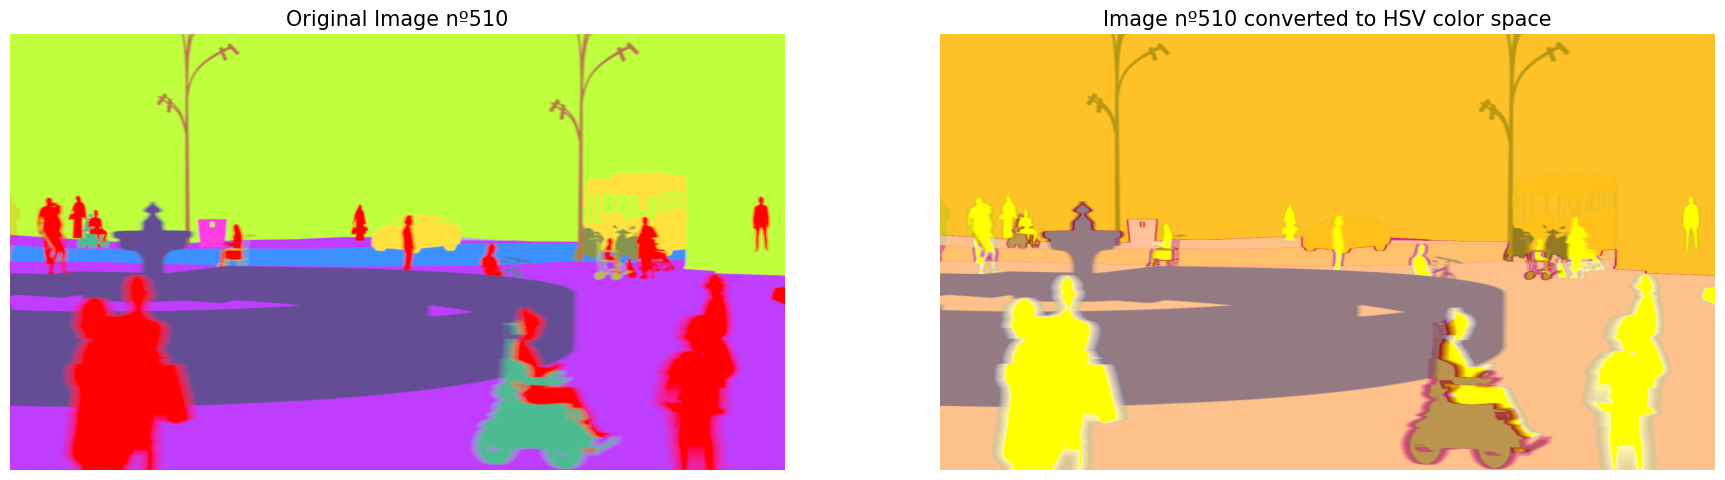

In [ ]:
import sys
import os

# Add the project root folder path to sys.path
# project_path = '/home/santiago/Doctorado/Entrenamientos/renato/pucpr_pibic_semantic_segmentation'
project_path = '/media/renato/Data/Work/pucpr_pibic_semantic_segmentation/'
sys.path.append(os.path.abspath(project_path))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
# base_mask_folder: str = r"C:\Users\SLR02\Pictures\prueba 3\FinalImagePPM_Mask"
# output_folder: str = os.getenv("OUTPUT_FOLDER")
# mask_path: str = os.path.join(base_mask_folder, f"{441}.png")

base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)

# Setup Plot
plt.figure(figsize=[22,22])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Original Image nº{img_number}",fontdict={'fontsize': 15})
plt.axis('off')
# Plotting HSV image
plt.subplot(122)
plt.imshow(hsv_img[:,:,::-1])
plt.title(f"Image nº{img_number} converted to HSV color space",fontdict={'fontsize': 15})
plt.axis('off')

In [7]:
# Inspect the actual color values ​​in the image for each pixel
# cv.imshow("Inspect Image", bgr_img)
cv.imshow("Inspect Image", hsv_img)
cv.waitKey(0)
cv.destroyAllWindows()


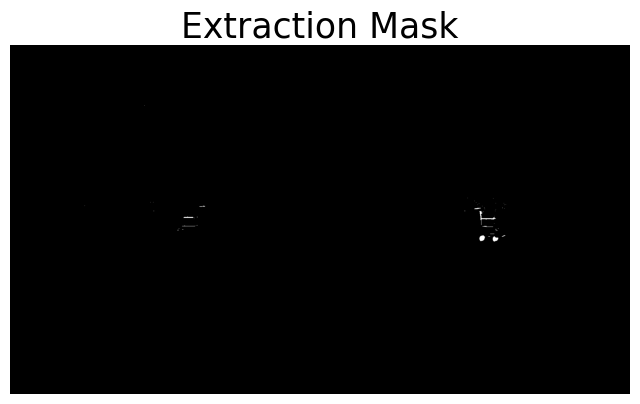

In [9]:
### Process 1 - Extraction of the desired color ###
# Define limits for the color you want to extract in HSV
lower_bound = np.array([20, 140, 178]) # Hue, Saturation, Value
upper_bound = np.array([31, 151, 198]) # Hue, Saturation, Value
mask_extraction = cv.inRange(hsv_img, lower_bound, upper_bound)

# Display the extraction mask
plt.figure(figsize=[8, 8])
plt.imshow(mask_extraction, cmap='gray')
plt.title("Extraction Mask", fontdict={'fontsize': 25})
plt.axis('off')
plt.show()


(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

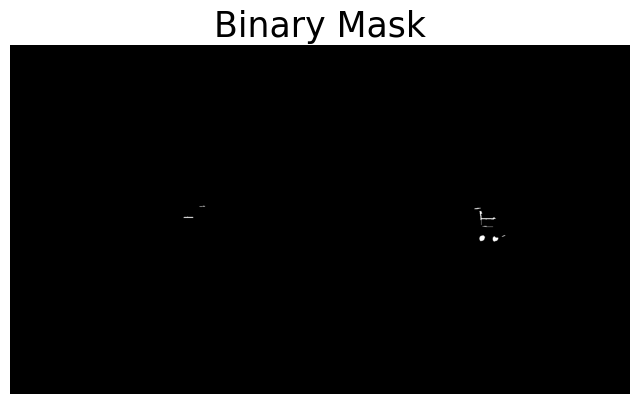

In [10]:
### Process 2 - Find Contours and Remove Noise
contours, hierarchy = cv.findContours(mask_extraction, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

# Create empty mask
filtered_mask = np.zeros_like(mask_extraction)

# Define minimum area
min_area = 5

# Filter by area and preserve structure
for contour in contours:
    area = cv.contourArea(contour)
    if area >= min_area:
        # Create mask for this specific contour
        temp_mask = np.zeros_like(mask_extraction)
        cv.drawContours(temp_mask, [contour], -1, (255), -1)
        
        # Preserve original pixels within outline
        contour_region = cv.bitwise_and(mask_extraction, temp_mask)
        filtered_mask = cv.bitwise_or(filtered_mask, contour_region)

# 3.4 - Visualize updated mask
plt.figure(figsize=[8,8])
plt.imshow(filtered_mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')


In [11]:
# Inspect the actual color values ​​in the image for each pixel
cv.imshow("Inspect Image", hsv_img)
cv.waitKey(0)
cv.destroyAllWindows()

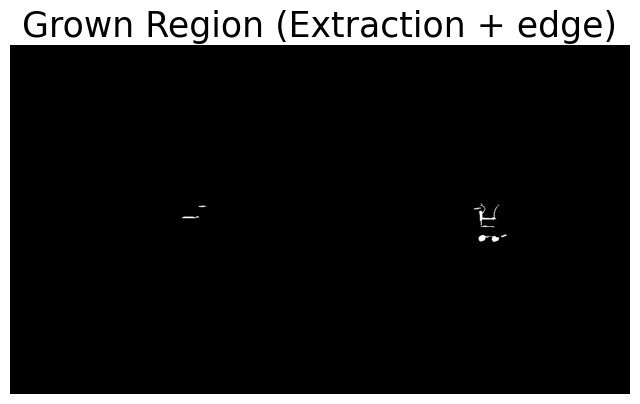

In [12]:
### Process 3 - Region Growth
import collections


### Define target color ###
# Average extraction range: ((25+31)//2, (136+151)//2, (188+198)//2) = [28, 143, 193]
target_color = np.array([(25 + 31) // 2, (136 + 151) // 2, (188 + 198) // 2])

### Region growing from extraction ###
# A region growing mask is created. Initially, it contains the extraction.
region_mask = np.zeros_like(filtered_mask, dtype=np.uint8)
region_mask[filtered_mask == 255] = 255

# We use a queue to implement region growth
queue = collections.deque()

# We add the initial pixels of the extraction
indexes = np.column_stack(np.where(filtered_mask == 255))
for index in indexes:
    queue.append(tuple(index))

# Helper function: boundary condition based on the obtained ranges in HSV
def fulfill_condition(H, S, V):
    return ((12 <= H <= 34) and (41 <= S <= 180) and (172 <= V <= 213)) # Adjusted values for growth, good results in general
    # return ((28 <= H <= 33) and (41 <= S <= 180) and (183 <= V <= 213)) # Better for blur effect but bad results for other images


# We perform the growth: for each pixel in the region, its neighbors are analyzed.
while queue:
    i, j = queue.popleft()
    # For 8 Neighbors (it's possible expand the neighborhood if necessary)
    for di, dj in [
                    (-1, -1), (-1, 0), (-1, 1),
                    ( 0, -1),          ( 0, 1),
                    ( 1, -1), ( 1, 0), ( 1, 1)
                ]:
        ni, nj = i + di, j + dj
        # Check that the neighbor is within the image
        if 0 <= ni < hsv_img.shape[0] and 0 <= nj < hsv_img.shape[1]:
            # If the neighbor is not yet part of the growth region:
            if region_mask[ni, nj] == 0:
                H, S, V = hsv_img[ni, nj]
                if fulfill_condition(H, S, V):
                    region_mask[ni, nj] = 255
                    queue.append((ni, nj))

# Display the grown region
plt.figure(figsize=[8, 8])
plt.imshow(region_mask, cmap='gray')
plt.title("Grown Region (Extraction + edge)", fontdict={'fontsize': 25})
plt.axis('off')
plt.show()


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

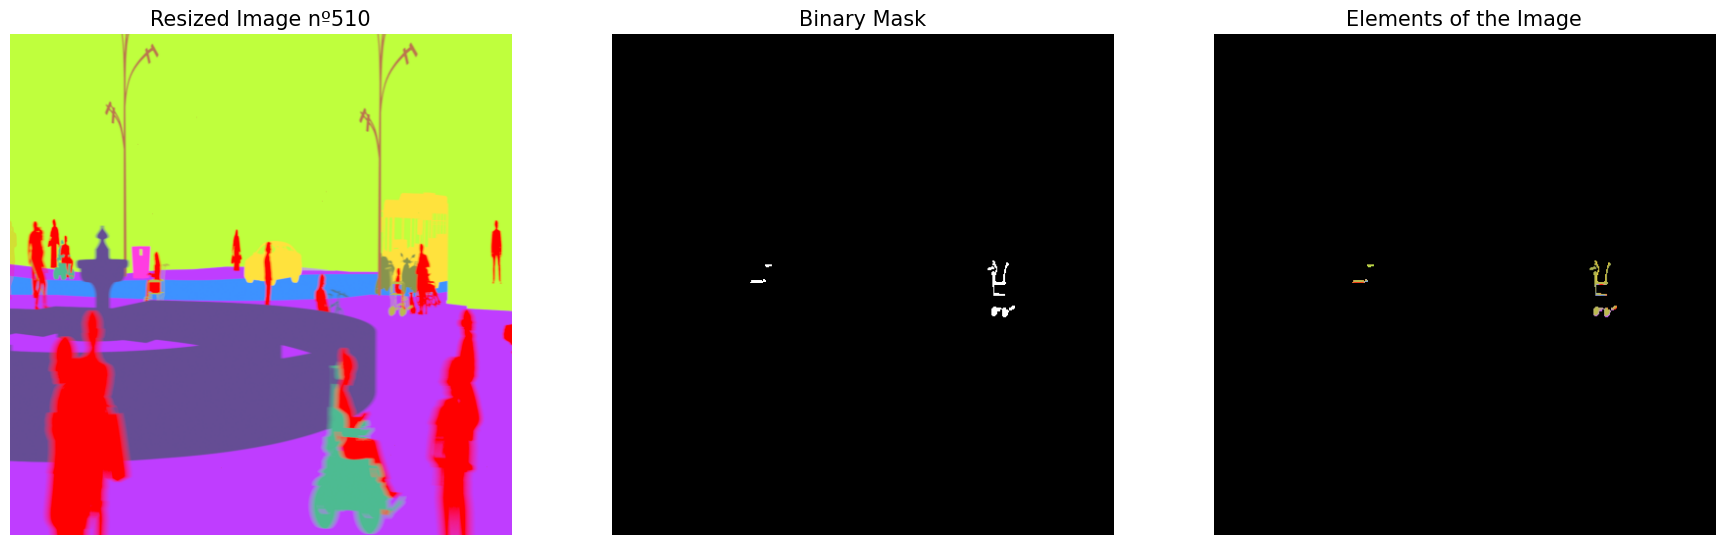

In [13]:
# Morphologic Operation
# 3. Post-processing
kernel = np.ones((2,2), np.uint8)
mask = cv.morphologyEx(region_mask, cv.MORPH_CLOSE, kernel) # Close small holes


# Resize mask and image
resized_mask = cv.resize(mask, (512, 512), interpolation=cv.INTER_AREA)
binary_mask = np.where(resized_mask > 0, 255, 0).astype(np.uint8) # threshold = 0


# Visualize Segmentation
# Resize Original Image
bgr_img = cv.resize(bgr_img, (512, 512), interpolation=cv.INTER_AREA)
# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=binary_mask)

# Setup Plot
plt.figure(figsize=[22,22])
# Plotting original image
plt.subplot(131)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Resized Image nº{img_number}",fontdict={'fontsize': 15})
plt.axis('off')
# Plotting binary mask
plt.subplot(132)
plt.imshow(binary_mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 15})
plt.axis('off')
# Plotting result
plt.subplot(133)
plt.imshow(result[:,:,::-1])
plt.title("Elements of the Image",fontdict={'fontsize':15})
plt.axis('off')

In [14]:
cv.imshow("Inspect Image", result)
cv.waitKey(0)
cv.destroyAllWindows()

Alternative

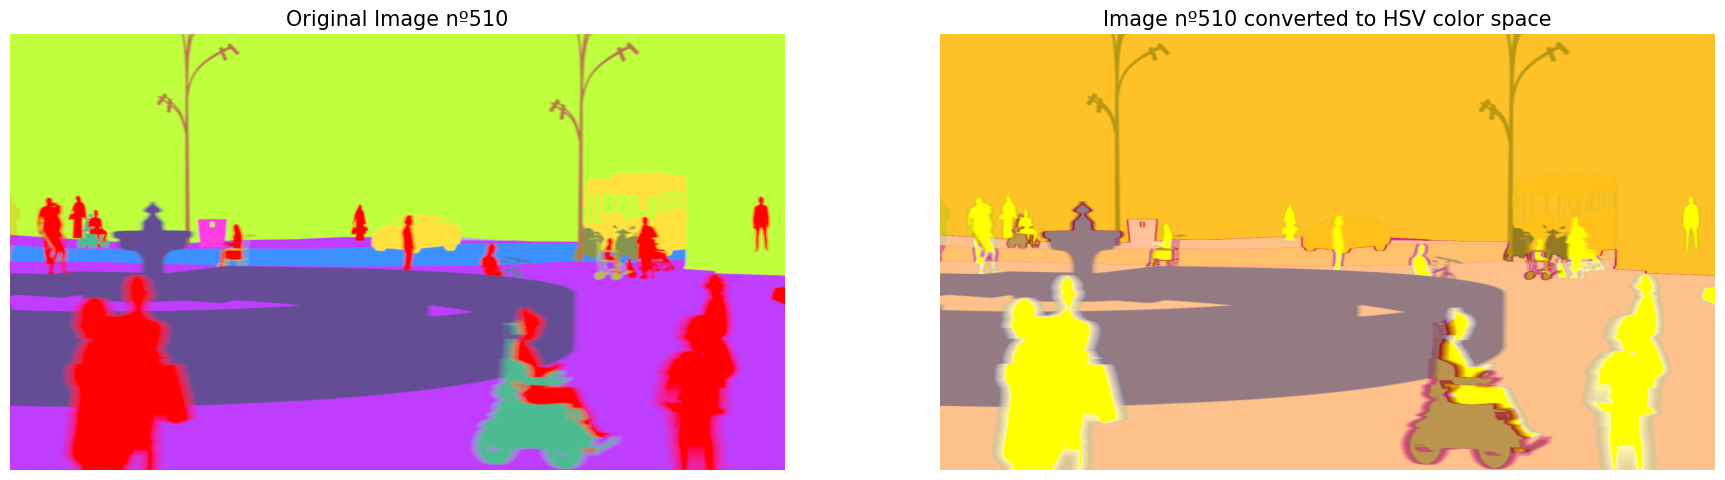

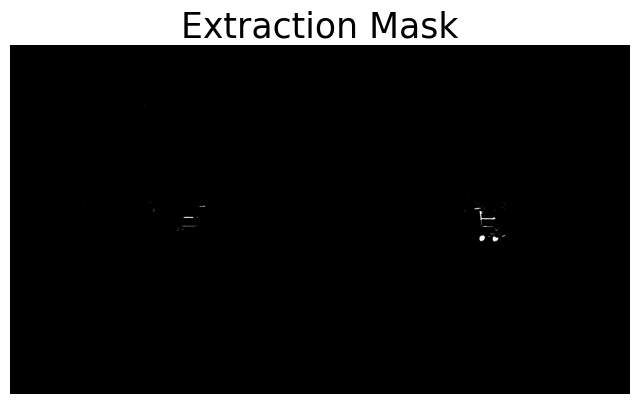

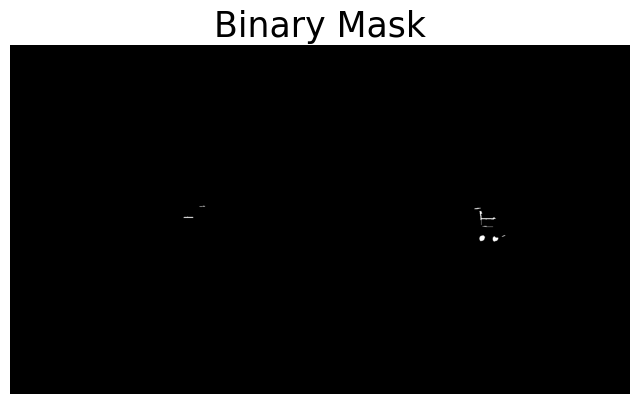

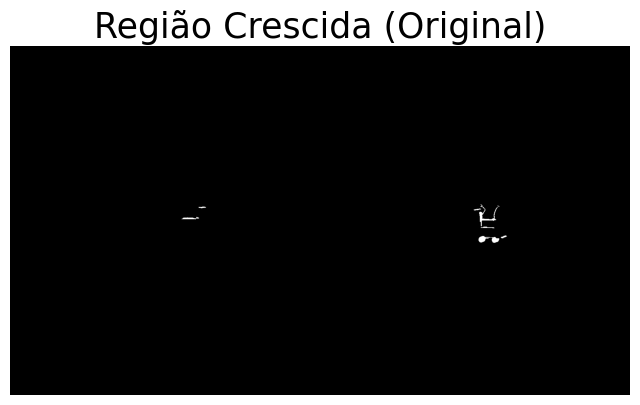

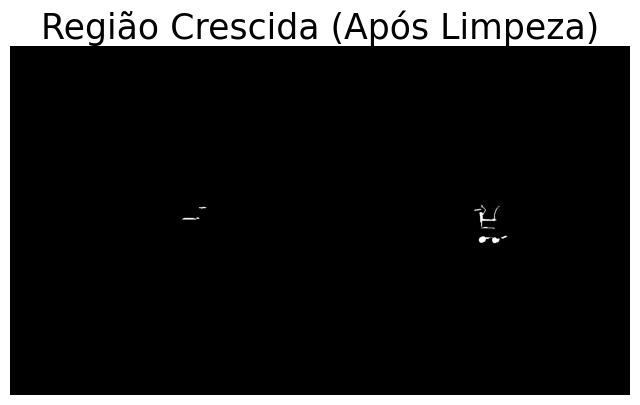

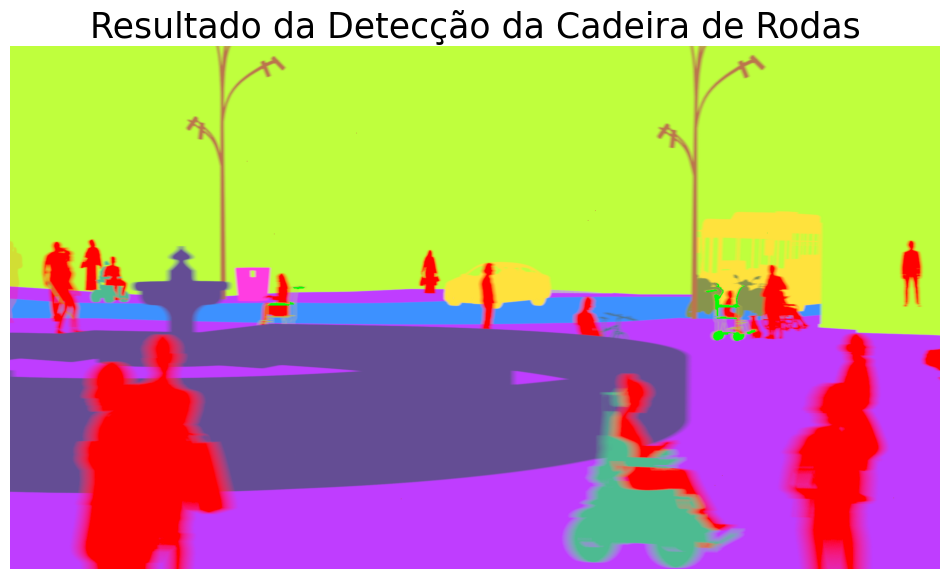

In [ ]:
import sys
import os
import collections
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from core.validation import get_valid_image_number

### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)

# Setup Plot
plt.figure(figsize=[22,22])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Original Image nº{img_number}",fontdict={'fontsize': 15})
plt.axis('off')
# Plotting HSV image
plt.subplot(122)
plt.imshow(hsv_img[:,:,::-1])
plt.title(f"Image nº{img_number} converted to HSV color space",fontdict={'fontsize': 15})
plt.axis('off')

### Process 1 - Extraction of the desired color ###
# Define limits for the wheelchair color in HSV
lower_bound = np.array([20, 140, 178]) # Hue, Saturation, Value
upper_bound = np.array([34, 151, 198]) # Hue, Saturation, Value
mask_extraction = cv.inRange(hsv_img, lower_bound, upper_bound)

# Display the extraction mask
plt.figure(figsize=[8, 8])
plt.imshow(mask_extraction, cmap='gray')
plt.title("Extraction Mask", fontdict={'fontsize': 25})
plt.axis('off')
plt.show()

### Process 2 - Find Contours and Remove Noise
contours, hierarchy = cv.findContours(mask_extraction, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

# Create empty mask
filtered_mask = np.zeros_like(mask_extraction)

# Define minimum area
min_area = 5

# Filter by area and preserve structure
for contour in contours:
    area = cv.contourArea(contour)
    if area >= min_area:
        # Create mask for this specific contour
        temp_mask = np.zeros_like(mask_extraction)
        cv.drawContours(temp_mask, [contour], -1, (255), -1)
        
        # Preserve original pixels within outline
        contour_region = cv.bitwise_and(mask_extraction, temp_mask)
        filtered_mask = cv.bitwise_or(filtered_mask, contour_region)

# Visualize updated mask
plt.figure(figsize=[8,8])
plt.imshow(filtered_mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')
plt.show()

### Process 3 - Region Growth with Improved HSV Conditions

# SOLUÇÃO 1: Ajustar os limites HSV para evitar a motocicleta
# Define a função de condição para o crescimento de região
def fulfill_condition(H, S, V):
    # Evita a motocicleta restringindo Hue para valores menores que 35
    wheelchair_condition = (6 <= H <= 34) and (41 <= S <= 180) and (172 <= V <= 213)
    
    # Exclusão explícita dos valores da motocicleta
    motorcycle_condition = (25 <= H <= 36) and (122 <= S <= 123) and (148 <= V <= 149)
    
    # Exclusão explícita dos valores de postes de luz (OK)
    street_light_condition = (11 <= H <= 13) and (146 <= S <= 158) and (187 <= V <= 188)
    
    # Retorna True se satisfaz a condição da cadeira de rodas E não é uma motocicleta E não é um poste de luz
    return wheelchair_condition and not motorcycle_condition and not street_light_condition

# Cria a máscara de região crescida a partir da extração filtrada
region_mask = np.zeros_like(filtered_mask, dtype=np.uint8)
region_mask[filtered_mask == 255] = 255

# Fila para o crescimento de região
queue = collections.deque()

# Adiciona os pixels iniciais da extração filtrada
indexes = np.column_stack(np.where(filtered_mask == 255))
for index in indexes:
    queue.append(tuple(index))

# Realiza o crescimento de região
while queue:
    i, j = queue.popleft()
    # Verifica os 8 vizinhos
    for di, dj in [
                (-1, -1), (-1, 0), (-1, 1),
                ( 0, -1),          ( 0, 1),
                ( 1, -1), ( 1, 0), ( 1, 1)
            ]:
        ni, nj = i + di, j + dj
        # Verifica se o vizinho está dentro da imagem
        if 0 <= ni < hsv_img.shape[0] and 0 <= nj < hsv_img.shape[1]:
            # Se o vizinho ainda não faz parte da região
            if region_mask[ni, nj] == 0:
                H, S, V = hsv_img[ni, nj]
                if fulfill_condition(H, S, V):
                    region_mask[ni, nj] = 255
                    queue.append((ni, nj))

# SOLUÇÃO 2: Aplicar operações morfológicas para limpeza
kernel = np.ones((2, 2), np.uint8)
region_mask_clean = cv.morphologyEx(region_mask, cv.MORPH_CLOSE, kernel)  # Fecha pequenos buracos
# region_mask_clean = cv.morphologyEx(region_mask_clean, cv.MORPH_OPEN, kernel)  # Remove pequenos ruídos

# SOLUÇÃO 3: Remover componentes pequenos ou isolados
# Identifica os componentes conectados e suas áreas
num_labels, labels, stats, centroids = cv.connectedComponentsWithStats(region_mask_clean, connectivity=8)

# Cria uma máscara para o resultado final
final_mask = np.zeros_like(region_mask_clean)

# Área mínima para considerar um componente válido
min_component_area = 50

# Copia apenas os componentes grandes o suficiente
for i in range(1, num_labels):  # Começa em 1 para pular o fundo (0)
    component_area = stats[i, cv.CC_STAT_AREA]
    if component_area > min_component_area:
        final_mask[labels == i] = 255

# Exibe a região crescida original
plt.figure(figsize=[8, 8])
plt.imshow(region_mask, cmap='gray')
plt.title("Região Crescida (Original)", fontdict={'fontsize': 25})
plt.axis('off')
plt.show()

# Exibe a região crescida após limpeza
plt.figure(figsize=[8, 8])
plt.imshow(final_mask, cmap='gray')
plt.title("Região Crescida (Após Limpeza)", fontdict={'fontsize': 25})
plt.axis('off')
plt.show()

# Visualização do resultado sobre a imagem original
result_img = bgr_img.copy()
result_img[final_mask == 255] = [0, 255, 0]  # Destaca a cadeira de rodas em verde

plt.figure(figsize=[12, 12])
plt.imshow(result_img[:,:,::-1])
plt.title("Resultado da Detecção da Cadeira de Rodas", fontdict={'fontsize': 25})
plt.axis('off')
plt.show()


In [100]:
# Inspect the actual color values ​​in the image for each pixel
# cv.imshow("Inspect Image", hsv_img)
cv.imshow("Inspect Image", result_img)

# result_hsv_img = cv.cvtColor(result_img, cv.COLOR_BGR2HSV)
# cv.imshow("Inspect Image", result_hsv_img)
cv.waitKey(0)
cv.destroyAllWindows()